
# TrappedAtomsSimulation_DipolePotential

Author: Paul Christ

Date: 04.11.2025


In [1]:
!pip install -qq "git+https://github.com/christpaul94/MD1912.git#subdirectory=MolecularDynamics"

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.2/552.2 kB 10.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 kB 28.8 MB/s eta 0:00:00


In [2]:
# Import
from TrappedAtomsSimulation.initialization import initialize_one_temp_gaussian_state, initialize_two_temp_gaussian_state
from TrappedAtomsSimulation.force_calculation import calculate_interaction_strength
from TrappedAtomsSimulation.force_calculation import pair_keops_fp
from TrappedAtomsSimulation.integrators import run_verlet_simulation_HO, solve_harmonic_analytical, run_verlet_simulation_general, run_verlet_simulation_dynamic, run_harmonic_splitting_simulation
from TrappedAtomsSimulation.plot_utils import plot_energy_and_error, plot_thermalization
from TrappedAtomsSimulation.trap_potential_extended import calculate_single_beam_X_AXIS, calculate_single_beam_Y_AXIS, calculate_crossed_beam_dipole_potential, calculate_U0, calculate_crossed_trap_frequencies
#rom TrappedAtomsSimulation.verlet_list_force_calculation import run_verlet_list_simulation_general
from TrappedAtomsSimulation.initialization_rejection_sampling import prepare_one_temp_simulation_rejection, prepare_two_temp_simulation_rejection


import torch
import math
import time

[KeOps] Compiling cuda jit compiler engine ... OK
[pyKeOps] Compiling nvrtc binder for python ... OK


In [16]:
def plot_angular_momentum_and_error(q, p, t):
    # Berechne das Drehmoment (L = q x p)
    angular_momentum = torch.cross(q, p, dim=2).sum(dim=1)
    angular_momentum_x, angular_momentum_y, angular_momentum_z = angular_momentum[:, 0].cpu().numpy(), angular_momentum[:, 1].cpu().numpy(), angular_momentum[:, 2].cpu().numpy()
    angular_momentum_magnitude = np.sqrt(angular_momentum_x**2 + angular_momentum_y**2 + angular_momentum_z**2)

    # Berechne die relative Abweichung für jede Komponente
    Lx0 = angular_momentum_x[0]
    Ly0 = angular_momentum_y[0]
    Lz0 = angular_momentum_z[0]
    L_magnitude0 = angular_momentum_magnitude[0]

   # delta_Lx_rel = np.abs(angular_momentum_x - Lx0) / np.abs(Lx0)
  #  delta_Ly_rel = np.abs(angular_momentum_y - Ly0) / np.abs(Ly0)
 #   delta_Lz_rel = np.abs(angular_momentum_z - Lz0) / np.abs(Lz0)
#    delta_L_magnitude_rel = np.abs(angular_momentum_magnitude - L_magnitude0) / np.abs(L_magnitude0)

    # Erstelle Subplots: 2 Zeilen und 1 Spalte
    fig, ax = plt.subplots(1, 1, figsize=(10, 4), sharex=True)

    # 1. Plot: Drehmoment-Komponenten
    ax.plot(t.cpu().numpy(), angular_momentum_x, label='Lx')
    ax.plot(t.cpu().numpy(), angular_momentum_y, label='Ly')
    ax.plot(t.cpu().numpy(), angular_momentum_z, label='Lz')
    ax.plot(t.cpu().numpy(), angular_momentum_magnitude, label='|L|', linestyle='--')

    ax.set_xlabel('Time')
    ax.set_ylabel('Angular Momentum')
    ax.set_title('Angular Momentum vs Time')
    ax.legend()
    ax.grid()

    # 2. Plot: Fehler (Relative Abweichung)
  #  ax[1].plot(t.cpu().numpy(), delta_Lx_rel, label='Relative Error (Lx)')
  #  ax[1].plot(t.cpu().numpy(), delta_Ly_rel, label='Relative Error (Ly)')
  #  ax[1].plot(t.cpu().numpy(), delta_Lz_rel, label='Relative Error (Lz)')
  #  ax[1].plot(t.cpu().numpy(), delta_L_magnitude_rel, label='Relative Error (|L|)', linestyle='--')

  #  ax[1].set_yscale('log')  # Log-Scale für Fehlerdarstellung
  #  ax[1].set_xlabel('Time')
  #  ax[1].set_ylabel('Relative Error')
  #  ax[1].set_title('Relative Error in Angular Momentum Components')
  #  ax[1].legend()
  #  ax[1].grid()

    # Layout anpassen
    plt.tight_layout()
    plt.show()


In [3]:
### troch settings
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

import torch._dynamo
torch._dynamo.config.capture_scalar_outputs = True


/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype = torch.float32
kB = 1.380649e-23  # J/K
c_light = 299_792_458.0 # m/s
pi = math.pi

--- Berechnete Potentialtiefen (U0) ---
  Strahl 1: -294.8 µK 
  Strahl 2: -294.8 µK 

--- Berechnete Frequenzen (basierend auf U0) ---
  f_x: 1305 Hz
  f_y: 1305 Hz
  f_z: 1845 Hz
  f_mean: 1464 Hz

--- Initialisiere N=12000 Teilchen ---
--- Skalierung basierend auf T = 5.00e-06 K ---
Längenskala L0: 2.67e-06 m, Energieskala E0: 6.90e-29 J, Zeitskala T0: 1.22e-04 s
Initialisiere 12000 Teilchen bei T = 5.00e-06 K
--- Initialisierung abgeschlossen ---

--- Skalierung basierend auf T_ref = 5.00e-06 K ---
Längenskala L0: 2.67e-06 m, Energieskala E0: 6.90e-29 J...
Verwende Bounding Box basierend auf T = 5.00e-06 K.
Initialisiere Gruppe (N=12000, T=5.00e-06 K)...
  -> Starte Rejection Sampling für 12000 Teilchen (T/T_ref = 1.00)...
  -> Sampling beendet. Akzeptanzrate: 0.06%
Dimensionslose Paar-Parameter: r=0.02944, c=9.620e-24
--- Ein-Temperatur-Initialisierung abgeschlossen ---


>>> Starte Simulation 1: Velocity Verlet (Standard)
Integration 100% | ETA: 0 min 0 s
Integration abgeschlosse

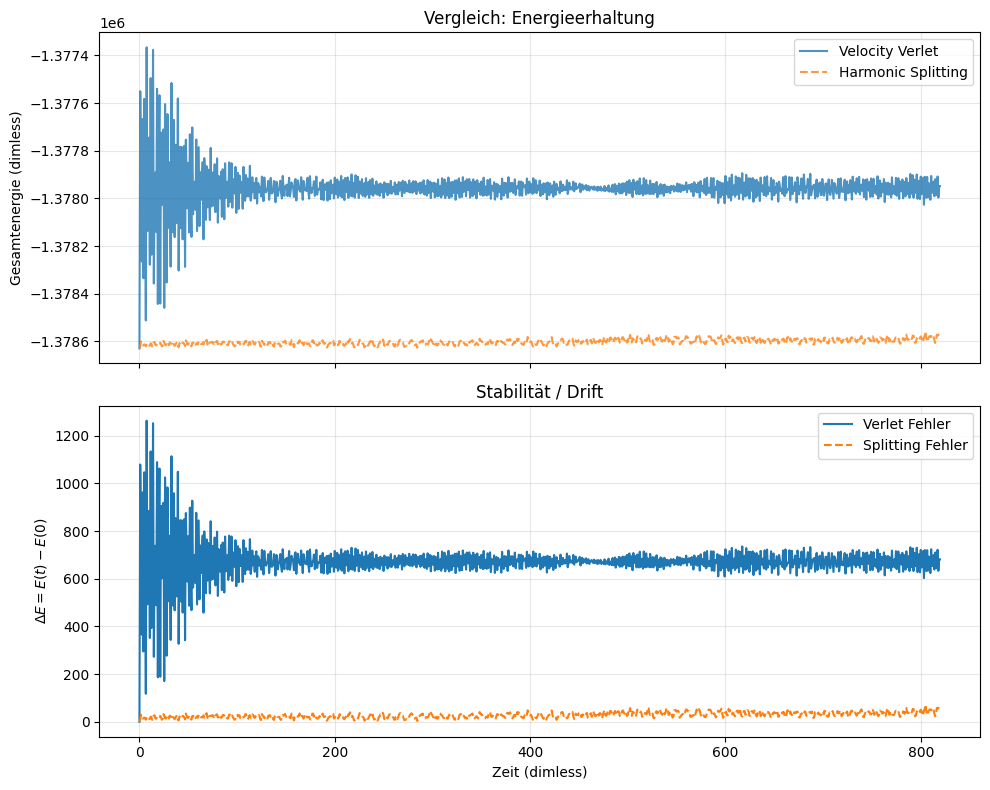

In [22]:
import torch
import time
import matplotlib.pyplot as plt
from typing import Dict, Callable, Tuple
import numpy as np

# =============================================================================
# 1. DEFINITION: OPTIMIERTER HARMONIC SPLITTING ALGORITHMUS
# =============================================================================

def run_splitting_simulation_optimized(
    t_values: torch.Tensor,
    q0: torch.Tensor,
    p0: torch.Tensor,
    omega_matrix: torch.Tensor,      # Tensor der Frequenzen (dimless)
    trap_force_func: Callable,       # Berechnet volle externe Falle
    trap_force_params: Dict,
    pair_force_func: Callable,       # Berechnet Paarwechselwirkung
    pair_force_params: Dict,
    mass: float = 1.0,               # In dimless units meist 1.0
    precision_type: torch.dtype = torch.float32,
    device: torch.device = torch.device('cpu'),
    substeps: int = 100,
    **kwargs
) -> Dict[str, torch.Tensor]:
    """
    Führt eine Simulation mittels Harmonic Splitting (Symplectic Integrator) durch.
    Optimiert durch Vorberechnung der Rotationsterme außerhalb der inneren Schleife.
    """
    with torch.no_grad():
        num_save_points, n_particles = t_values.size(0), q0.size(0)

        # Output Arrays
        q_out = torch.empty((num_save_points, n_particles, 3), dtype=precision_type, device=device)
        p_out = torch.empty((num_save_points, n_particles, 3), dtype=precision_type, device=device)
        kinetic_energy_out = torch.empty(num_save_points, dtype=precision_type, device=device)
        potential_trap_out = torch.empty(num_save_points, dtype=precision_type, device=device)
        potential_pair_out = torch.empty(num_save_points, dtype=precision_type, device=device)

        # Initialisierung
        q_current = q0.to(device, precision_type)
        p_current = p0.to(device, precision_type)

        # Frequenzen extrahieren
        omegas = torch.diagonal(omega_matrix).to(device, precision_type)
        # Broadcasting sicherstellen (1, 3) für (N, 3) Operationen
        if omegas.ndim == 1:
            omegas = omegas.unsqueeze(0)

        # --- Hilfsfunktion: Restkraft berechnen ---
        # F_rest = F_real_trap + F_pair - F_harmonic_ideal
        def get_residual_forces(q):
            # 1. Volle externe Falle (z.B. Crossed Beam)
            f_trap, pot_trap, _ = trap_force_func(q, **trap_force_params)

            # 2. Paarwechselwirkung
            f_pair, pot_pair = pair_force_func(q, **pair_force_params)

            # 3. Abzug der idealen harmonischen Kraft (die wir analytisch lösen)
            # Formel: F = -m * w^2 * q (mit m=1)
            f_ref = - mass * (omegas**2) * q

            # Restkraft für den Verlet-Kick
            f_residual = (f_trap + f_pair) - f_ref

            return f_residual, pot_trap, pot_pair

        # Startwerte setzen
        q_out[0], p_out[0] = q_current, p_current
        kinetic_energy_out[0] = 0.5 * torch.sum(p_current**2) / mass

        f_res_current, pot_t, pot_p = get_residual_forces(q_current)
        potential_trap_out[0], potential_pair_out[0] = pot_t, pot_p

        # --- Hauptschleife ---
        for i in range(1, num_save_points):
            Dt = t_values[i] - t_values[i - 1]
            dt = Dt / substeps

            # --- VORBERECHNUNG DER ROTATION (Performance Boost) ---
            # Da dt in diesem Intervall konstant ist, berechnen wir die
            # Rotationsmatrix-Elemente nur 1x statt substeps-mal.
            c_step = torch.cos(omegas * dt)
            s_step = torch.sin(omegas * dt)

            # Vorfaktoren für die Update-Gleichungen
            s_over_w = s_step / omegas
            w_times_s = omegas * s_step * mass # mass=1 usually

            # --- INNERE SCHLEIFE (Symplectic Splitting) ---
            for _ in range(substeps):
                # 1. KICK (dt/2) mit Restkräften
                p_current = p_current + 0.5 * dt * f_res_current

                # 2. DRIFT / ROTATION (dt) - Exakte harmonische Lösung
                # q_new = q * cos + p/m * (sin/w)
                # p_new = p * cos - q * (m*w*sin)
                q_next_rot = q_current * c_step + (p_current / mass) * s_over_w
                p_next_rot = p_current * c_step - q_current * w_times_s

                q_current = q_next_rot
                p_current = p_next_rot

                # Neue Kräfte am neuen Ort berechnen
                f_res_next, pot_t_next, pot_p_next = get_residual_forces(q_current)

                # 3. KICK (dt/2) mit neuen Restkräften
                p_current = p_current + 0.5 * dt * f_res_next

                # Update Kraft für nächsten Step
                f_res_current = f_res_next

            # Speichern
            q_out[i] = q_current
            p_out[i] = p_current
            kinetic_energy_out[i] = 0.5 * torch.sum(p_current**2) / mass
            potential_trap_out[i] = pot_t_next
            potential_pair_out[i] = pot_p_next

            if i % 10 == 0 or i == num_save_points - 1:
                print(f"\rSplitting Progress: {100 * i / num_save_points:.0f}%", end="")

        print("\nSplitting Integration abgeschlossen.")

        return {
            "times": t_values, "positions": q_out, "momenta": p_out,
            "kinetic_energy": kinetic_energy_out,
            "potential_energy_trap": potential_trap_out,
            "potential_energy_pair": potential_pair_out
        }

# =============================================================================
# 2. PHYSIKALISCHE PARAMETER & SETUP (Dein Code)
# =============================================================================

# Atommasse 87Rb
m_rb87 = 1.44160648e-25  # kg
kB = 1.380649e-23        # J/K (Boltzmann Konstante angenommen)
pi = torch.pi            # Nutzung von torch.pi

# D1 Linie
omega_0_D1 = 2 * pi * 377.1074635e12 # rad/s
Gamma_D1 = 2 * pi * 5.746e6         # rad/s

# D2 Linie
omega_0_D2 = 2 * pi * 384.230484e12 # rad/s
Gamma_D2 = 2 * pi * 6.065e6         # rad/s

# Laserfrequenz
omega_L = 2 * pi * 280.179867e12    # rad/s

# Strahl 1 (X-Achse)
P_x = 5.18      # W
w0_x_SI = 41e-6   # m (41 µm)
zR_x_SI = 4.94e-3 # m (4.94 mm)

# Strahl 2 (Y-Achse)
P_y = 6.52      # W
w0_y_SI = 46e-6   # m (46 µm)
zR_y_SI = 6.21e-3 # m (6.21 mm)

P_y = P_x
w0_y_SI = w0_x_SI
zR_y_SI = zR_x_SI

# Gemeinsame Atom/Laser-Parameter
atom_laser_params = {
    "omega_L": omega_L,
    "omega_0_D1": omega_0_D1, "Gamma_D1": Gamma_D1,
    "omega_0_D2": omega_0_D2, "Gamma_D2": Gamma_D2
}

# Berechne U0 für Strahl 1 & 2
U0_1_SI = calculate_U0(P=P_x, w0=w0_x_SI, **atom_laser_params)
U0_2_SI = calculate_U0(P=P_y, w0=w0_y_SI, **atom_laser_params)

U0_1_in_uK = (U0_1_SI / kB) * 1e6
U0_2_in_uK = (U0_2_SI / kB) * 1e6

print("--- Berechnete Potentialtiefen (U0) ---")
print(f"  Strahl 1: {U0_1_in_uK:.1f} µK ")
print(f"  Strahl 2: {U0_2_in_uK:.1f} µK ")

trap_frequencies = calculate_crossed_trap_frequencies(
    U0_1=U0_1_SI, w0_1=w0_x_SI, zR_1=zR_x_SI,
    U0_2=U0_2_SI, w0_2=w0_y_SI, zR_2=zR_y_SI,
    m=m_rb87
)

print("\n--- Berechnete Frequenzen (basierend auf U0) ---")
print(f"  f_x: {trap_frequencies['freq_x_hz']:.0f} Hz")
print(f"  f_y: {trap_frequencies['freq_y_hz']:.0f} Hz")
print(f"  f_z: {trap_frequencies['freq_z_hz']:.0f} Hz")
print(f"  f_mean: {trap_frequencies['freq_mean_hz']:.0f} Hz")

# --- Simulation Konfiguration ---
N_PARTICLES = 12000
TEMPERATURE_K = 5e-6
SIMULATION_TIME_S = 0.1
TIMESTEP_S = 1e-4
SUBSTEPS = 1

TRAP_FREQUENCIES_HZ = (trap_frequencies['freq_x_hz'], trap_frequencies['freq_y_hz'], trap_frequencies['freq_z_hz'])

# --- Physikalische Wechselwirkungsparameter ---
r0_phys, C_phys = calculate_interaction_strength(15)

print(f"\n--- Initialisiere N={N_PARTICLES} Teilchen ---")

# Bestimmt L0, E0, T0, q0, p0, r_dimless, c_dimless
sim_init_params = initialize_one_temp_gaussian_state(
    n_particles=N_PARTICLES,
    temp_k=TEMPERATURE_K,
    omega_phys_hz=TRAP_FREQUENCIES_HZ, # Verwendet harmonische Freq. für Start
    t_end_s=SIMULATION_TIME_S,
    dt_s=TIMESTEP_S,
    r0_phys=r0_phys,
    C_phys=C_phys/10,
    precision=torch.float32,
    device=device
)

# Skalierungsfaktoren
L0 = sim_init_params['L0_m']
E0 = sim_init_params['E0_J']
T0 = sim_init_params['T0_s']

# a) Parameter für die Dipolfalle
trap_params_extended = {
    "P_x": P_x, "P_y": P_y,
    "w0_x": w0_x_SI, "w0_y": w0_y_SI,
    "s0_x": zR_x_SI, "s0_y": zR_y_SI,
    "omega_L": omega_L,
    "omega_0_D1": omega_0_D1, "Gamma_D1": Gamma_D1,
    "omega_0_D2": omega_0_D2, "Gamma_D2": Gamma_D2,
    "L0": L0,
    "E0": E0
}

sim_init_params_rejection_sampling = prepare_one_temp_simulation_rejection(
    n_particles=N_PARTICLES,
    temp_k=TEMPERATURE_K,
    omega_phys_hz=TRAP_FREQUENCIES_HZ,
    t_end_s=SIMULATION_TIME_S,
    dt_s=TIMESTEP_S,
    r0_phys=r0_phys,
    C_phys=C_phys/1000000000000000000000,
    trap_force_func=calculate_crossed_beam_dipole_potential,
    trap_params=trap_params_extended,
    precision=torch.float32,
    device=device
)

# b) Parameter für die Paar-Wechselwirkung
pair_params = sim_init_params_rejection_sampling['pair_force_params']

# c) Basis Parameter für den Integrator
integrator_params = {
    "t_values": sim_init_params_rejection_sampling['t_values'],
    "q0": sim_init_params_rejection_sampling['q0'],
    "p0": sim_init_params_rejection_sampling['p0'],
    "precision_type": sim_init_params_rejection_sampling['precision_type'],
    "device": sim_init_params_rejection_sampling['device'],
    "substeps": SUBSTEPS,
}

# =============================================================================
# 3. AUSFÜHRUNG SIMULATION 1: VELOCITY VERLET (STANDARD)
# =============================================================================
print("\n>>> Starte Simulation 1: Velocity Verlet (Standard)")
start_time = time.perf_counter()

results_verlet = run_verlet_simulation_general(
    trap_force_func=calculate_crossed_beam_dipole_potential,
    trap_force_params=trap_params_extended,
    pair_force_func=pair_keops_fp,
    pair_force_params=pair_params,
    **integrator_params
)

duration_verlet = time.perf_counter() - start_time
print(f"Velocity Verlet abgeschlossen in {duration_verlet:.2f} Sekunden.")


# =============================================================================
# 4. AUSFÜHRUNG SIMULATION 2: HARMONIC SPLITTING (NEU)
# =============================================================================

# Vorbereitung: Frequenzen in dimensionslose Einheiten umrechnen (w_dimless = w_phys * T0)
freqs_hz_tensor = torch.tensor(TRAP_FREQUENCIES_HZ, device=device, dtype=torch.float32) *2 * pi
omegas_dimless = freqs_hz_tensor * T0
omega_matrix_dimless = torch.diag(omegas_dimless)

# Parameter für Splitting vorbereiten
splitting_params = integrator_params.copy()
splitting_params["omega_matrix"] = omega_matrix_dimless
splitting_params["mass"] = 1.0 # dimensionslos

print("\n>>> Starte Simulation 2: Harmonic Splitting (Optimiert)")
start_time = time.perf_counter()

results_splitting = run_splitting_simulation_optimized(
    trap_force_func=calculate_crossed_beam_dipole_potential,
    trap_force_params=trap_params_extended,
    pair_force_func=pair_keops_fp,
    pair_force_params=pair_params,
    **splitting_params
)

duration_split = time.perf_counter() - start_time
print(f"Splitting Simulation abgeschlossen in {duration_split:.2f} Sekunden.")


# =============================================================================
# 5. VERGLEICH UND PLOTTING
# =============================================================================

def compare_simulations(res_verlet, res_split):
    t = res_verlet['times'].cpu().numpy()

    # Energien berechnen (Verlet)
    E_tot_verlet = (res_verlet['kinetic_energy'] +
                    res_verlet['potential_energy_trap'] +
                    res_verlet['potential_energy_pair']).cpu().numpy()

    # Energien berechnen (Splitting)
    E_tot_split = (res_split['kinetic_energy'] +
                   res_split['potential_energy_trap'] +
                   res_split['potential_energy_pair']).cpu().numpy()

    # Drift relative zum Start
    drift_verlet = (E_tot_verlet - E_tot_verlet[0])
    drift_split = (E_tot_split - E_tot_split[0])

    fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # Plot 1: Absolute Energie
    ax[0].plot(t, E_tot_verlet, label='Velocity Verlet', alpha=0.8)
    ax[0].plot(t, E_tot_split, label='Harmonic Splitting', alpha=0.8, linestyle='--')
    ax[0].set_ylabel('Gesamtenergie (dimless)')
    ax[0].set_title('Vergleich: Energieerhaltung')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    # Plot 2: Energie-Fehler (Drift)
    ax[1].plot(t, drift_verlet, label='Verlet Fehler')
    ax[1].plot(t, drift_split, label='Splitting Fehler', linestyle='--')
    ax[1].set_ylabel(r'$\Delta E = E(t) - E(0)$')
    ax[1].set_xlabel('Zeit (dimless)')
    ax[1].set_title('Stabilität / Drift')
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Vergleichsplot aufrufen
print("\nErstelle Vergleichsplot...")
compare_simulations(results_verlet, results_splitting)

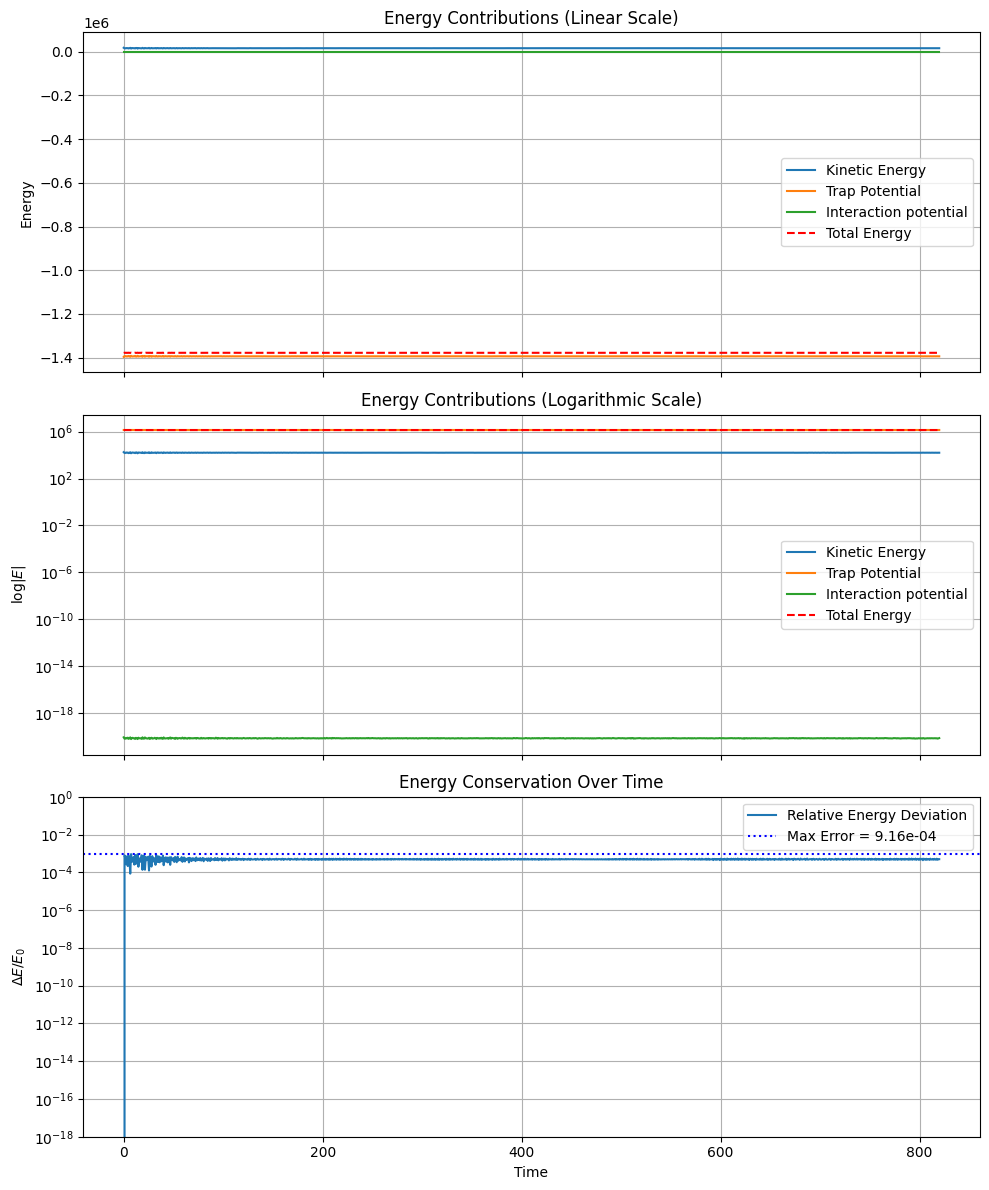

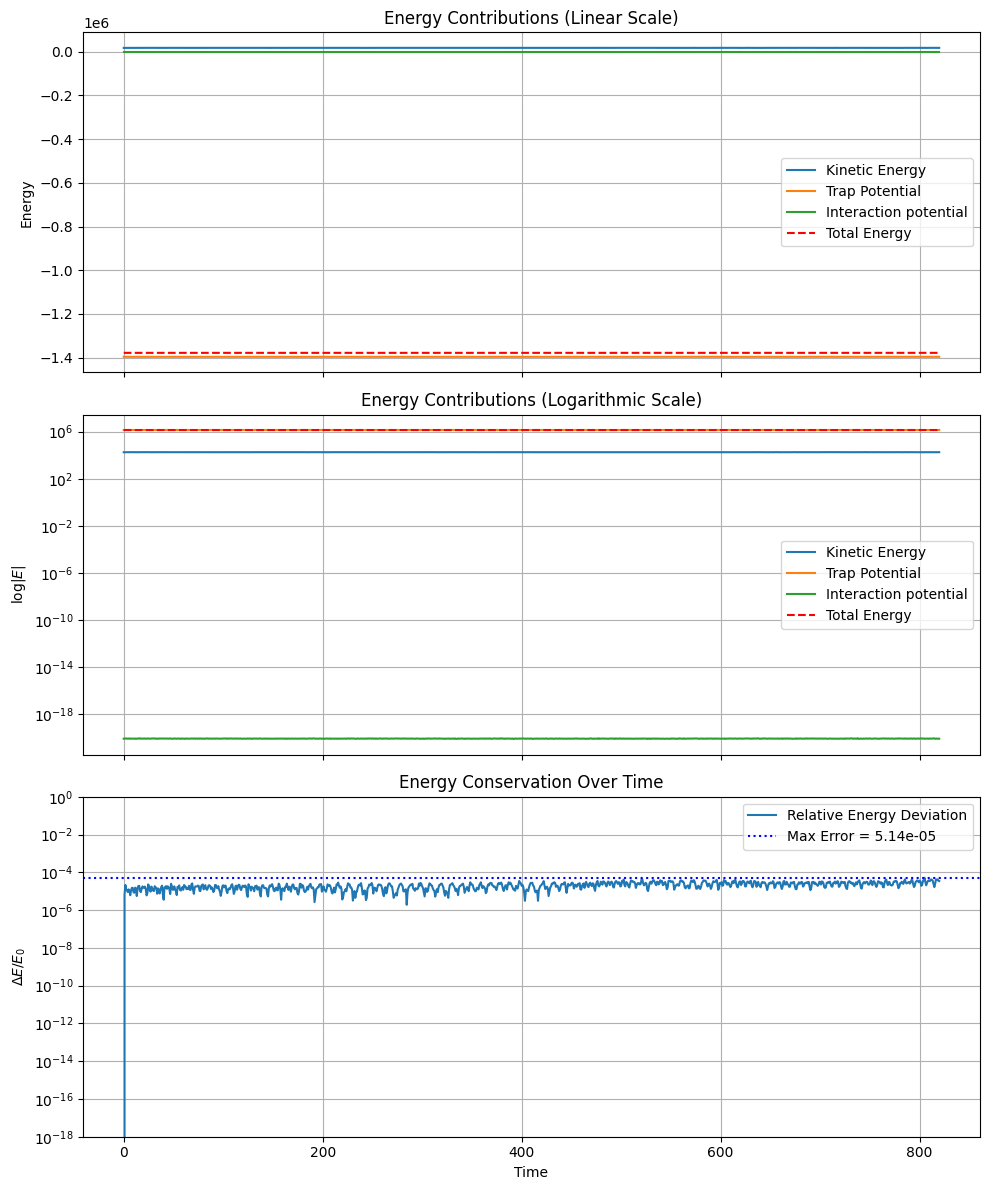

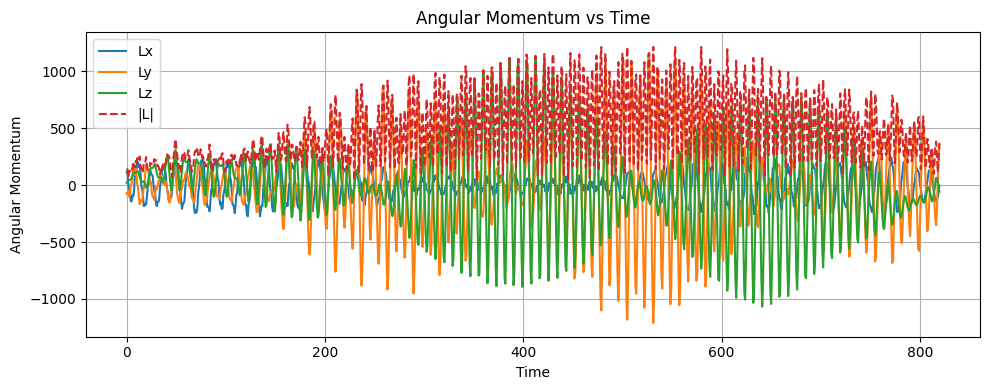

In [23]:

# --- 7. Ergebnisse plotten ---

plot_energy_and_error(
    results_verlet['times'],
    results_verlet['kinetic_energy'],
    results_verlet['potential_energy_trap'],
    results_verlet['potential_energy_pair']
)

plot_energy_and_error(
    results_splitting['times'],
    results_splitting['kinetic_energy'],
    results_splitting['potential_energy_trap'],
    results_splitting['potential_energy_pair']
)

plot_angular_momentum_and_error(results_verlet['positions'], results_verlet['momenta'], results_verlet['times'])

--- High-Speed Benchmark (dt = 500.0 µs) ---
Normalerweise benötigt Verlet dt << 1/omega_max.
Hier testen wir die Grenzen der Stabilität.

>>> Run 1: Velocity Verlet (Grobe Schritte)
Integration 100% | ETA: 0 min 0 s
Integration abgeschlossen.
Verlet fertig in 1.38 s

>>> Run 2: Harmonic Splitting (Grobe Schritte)
Splitting Progress: 100%
Splitting Integration abgeschlossen.
Splitting fertig in 0.93 s


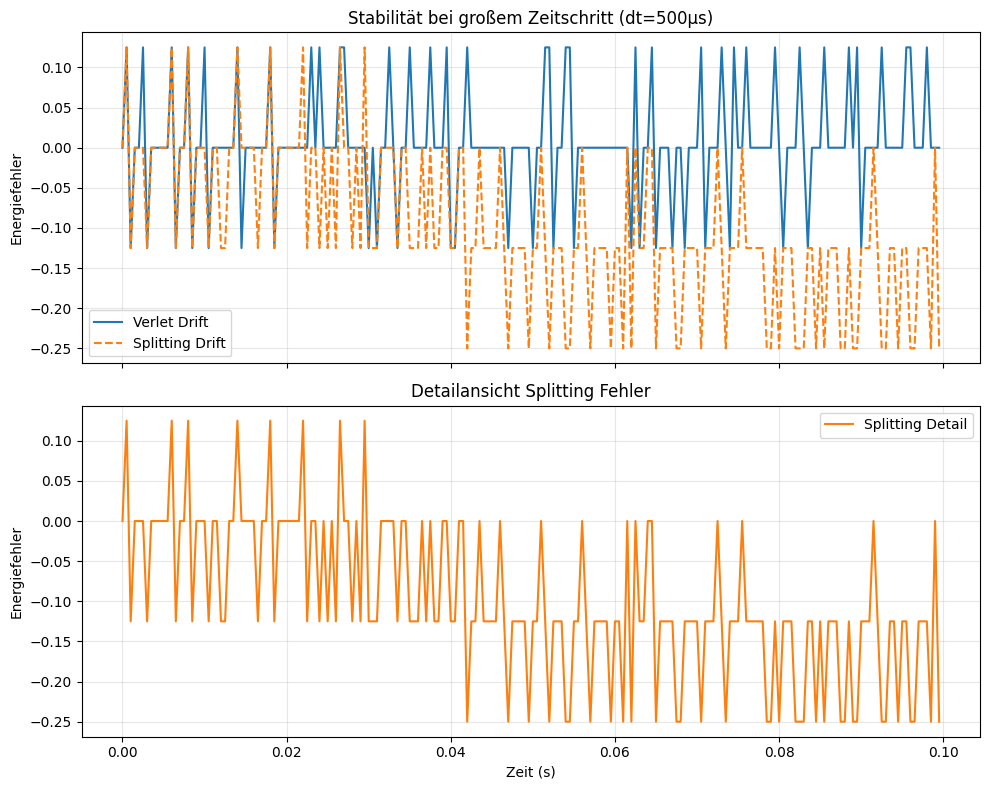

In [7]:
import torch
import time
import matplotlib.pyplot as plt

# --- PARAMETER FÜR DEN "HIGH-SPEED" TEST ---
# Wir machen es dem Integrator schwer:
# 1. Wir nutzen substeps=1 (keine Unterschritte zur Glättung)
# 2. Wir erhöhen den Zeitschritt künstlich (simulieren "grobe" Auflösung)

speed_factor = 5.0  # Wir machen den Zeitschritt 5x größer als normal
stress_dt = TIMESTEP_S * speed_factor

# Neue Zeit-Achse mit gröberen Schritten
t_stress = torch.arange(0, SIMULATION_TIME_S, stress_dt, device=device, dtype=torch.float32)

print(f"--- High-Speed Benchmark (dt = {stress_dt*1e6:.1f} µs) ---")
print(f"Normalerweise benötigt Verlet dt << 1/omega_max.")
print(f"Hier testen wir die Grenzen der Stabilität.")

# Setup Dictionary kopieren und anpassen
fast_params = integrator_params.copy()
fast_params["t_values"] = t_stress
fast_params["substeps"] = 1  # Ein einziger Schritt pro Speicherpunkt -> Hart für Verlet!
fast_params["omega_matrix"] = omega_matrix_dimless
fast_params["mass"] = 1.0


# =============================================================================
# 1. RUN: VELOCITY VERLET (wird ungenau)
# =============================================================================
print("\n>>> Run 1: Velocity Verlet (Grobe Schritte)")
start_v = time.perf_counter()

res_fast_verlet = run_verlet_simulation_general(
    trap_force_func=calculate_crossed_beam_dipole_potential, # Echte Dipolfalle!
    trap_force_params=trap_params_extended,
    pair_force_func=pair_keops_fp,
    pair_force_params=pair_params,
    **fast_params
)
print(f"Verlet fertig in {time.perf_counter()-start_v:.2f} s")


# =============================================================================
# 2. RUN: HARMONIC SPLITTING (sollte stabil bleiben)
# =============================================================================
print("\n>>> Run 2: Harmonic Splitting (Grobe Schritte)")
start_s = time.perf_counter()

res_fast_split = run_splitting_simulation_optimized(
    trap_force_func=calculate_crossed_beam_dipole_potential, # Echte Dipolfalle!
    trap_force_params=trap_params_extended,
    pair_force_func=pair_keops_fp,
    pair_force_params=pair_params,
    **fast_params
)
print(f"Splitting fertig in {time.perf_counter()-start_s:.2f} s")


# =============================================================================
# 3. VERGLEICH
# =============================================================================

def compare_fast_sims(res_v, res_s):
    t = res_v['times'].cpu().numpy()

    # Energien
    E_v = (res_v['kinetic_energy'] + res_v['potential_energy_trap'] + res_v['potential_energy_pair']).cpu().numpy()
    E_s = (res_s['kinetic_energy'] + res_s['potential_energy_trap'] + res_s['potential_energy_pair']).cpu().numpy()

    # Drift relative zum Startwert
    drift_v = E_v - E_v[0]
    drift_s = E_s - E_s[0]

    fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # Plot 1: Drift
    ax[0].plot(t, drift_v, label='Verlet Drift', color='tab:blue')
    ax[0].plot(t, drift_s, label='Splitting Drift', color='tab:orange', linestyle='--')
    ax[0].set_title(f'Stabilität bei großem Zeitschritt (dt={stress_dt*1e6:.0f}µs)')
    ax[0].set_ylabel('Energiefehler')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    # Plot 2: Zoom auf Splitting (um zu zeigen, dass es "bounded" ist)
    ax[1].plot(t, drift_s, label='Splitting Detail', color='tab:orange')
    ax[1].set_title('Detailansicht Splitting Fehler')
    ax[1].set_ylabel('Energiefehler')
    ax[1].set_xlabel('Zeit (s)')
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

compare_fast_sims(res_fast_verlet, res_fast_split)

## Trap

In [8]:
# Atommasse 87Rb
m_rb87 = 1.44160648e-25  # kg

# D1 Linie
omega_0_D1 = 2 * pi * 377.1074635e12 # rad/s
Gamma_D1 = 2 * pi * 5.746e6         # rad/s

# D2 Linie
omega_0_D2 = 2 * pi * 384.230484e12 # rad/s
Gamma_D2 = 2 * pi * 6.065e6         # rad/s

# Laserfrequenz
omega_L = 2 * pi * 280.179867e12    # rad/s




# Strahl 1 (X-Achse)
P_x = 5.18      # W
w0_x_SI = 41e-6   # m (41 µm)
zR_x_SI = 4.94e-3 # m (4.94 mm)

# Strahl 2 (Y-Achse)
P_y = 6.52      # W
w0_y_SI = 46e-6   # m (46 µm)
zR_y_SI = 6.21e-3 # m (6.21 mm)


# Gemeinsame Atom/Laser-Parameter
atom_laser_params = {
    "omega_L": omega_L,
    "omega_0_D1": omega_0_D1, "Gamma_D1": Gamma_D1,
    "omega_0_D2": omega_0_D2, "Gamma_D2": Gamma_D2
}



# Berechne U0 für Strahl 1
U0_1_SI = calculate_U0(P=P_x, w0=w0_x_SI, **atom_laser_params)

# Berechne U0 für Strahl 2
U0_2_SI = calculate_U0(P=P_y, w0=w0_y_SI, **atom_laser_params)

U0_1_in_uK = (U0_1_SI / kB) * 1e6
U0_2_in_uK = (U0_2_SI / kB) * 1e6

print("--- Berechnete Potentialtiefen (U0) ---")
print(f"  Strahl 1: {U0_1_in_uK:.1f} µK ")
print(f"  Strahl 2: {U0_2_in_uK:.1f} µK ")

trap_frequencies = calculate_crossed_trap_frequencies(
    U0_1=U0_1_SI, w0_1=w0_x_SI, zR_1=zR_x_SI,
    U0_2=U0_2_SI, w0_2=w0_y_SI, zR_2=zR_y_SI,
    m=m_rb87
)

print("\n--- Berechnete Frequenzen (basierend auf U0) ---")
print(f"  f_x: {trap_frequencies['freq_x_hz']:.0f} Hz")
print(f"  f_y: {trap_frequencies['freq_y_hz']:.0f} Hz")
print(f"  f_z: {trap_frequencies['freq_z_hz']:.0f} Hz")
print(f"  f_mean: {trap_frequencies['freq_mean_hz']:.0f} Hz")


--- Berechnete Potentialtiefen (U0) ---
  Strahl 1: -294.8 µK 
  Strahl 2: -294.8 µK 

--- Berechnete Frequenzen (basierend auf U0) ---
  f_x: 1163 Hz
  f_y: 1305 Hz
  f_z: 1747 Hz
  f_mean: 1384 Hz


## One group

--- Starte Simulation mit N=12062 Teilchen ---
--- Skalierung basierend auf T = 1.00e-06 K ---
Längenskala L0: 1.34e-06 m, Energieskala E0: 1.38e-29 J, Zeitskala T0: 1.37e-04 s
Initialisiere 12062 Teilchen bei T = 1.00e-06 K
--- Initialisierung abgeschlossen ---

--- Skalierung basierend auf T_ref = 1.00e-06 K ---
Längenskala L0: 1.34e-06 m, Energieskala E0: 1.38e-29 J...
Verwende Bounding Box basierend auf T = 1.00e-06 K.
Initialisiere Gruppe (N=12062, T=1.00e-06 K)...
  -> Starte Rejection Sampling für 12062 Teilchen (T/T_ref = 1.00)...
  -> Sampling beendet. Akzeptanzrate: 0.06%
Dimensionslose Paar-Parameter: r=0.03912, c=1.623e-03
--- Ein-Temperatur-Initialisierung abgeschlossen ---

Starte Simulation mit  Dipolfalle
Integration 100% | ETA: 0 min 0 s
Integration abgeschlossen.
Simulation abgeschlossen in 11.63 Sekunden.


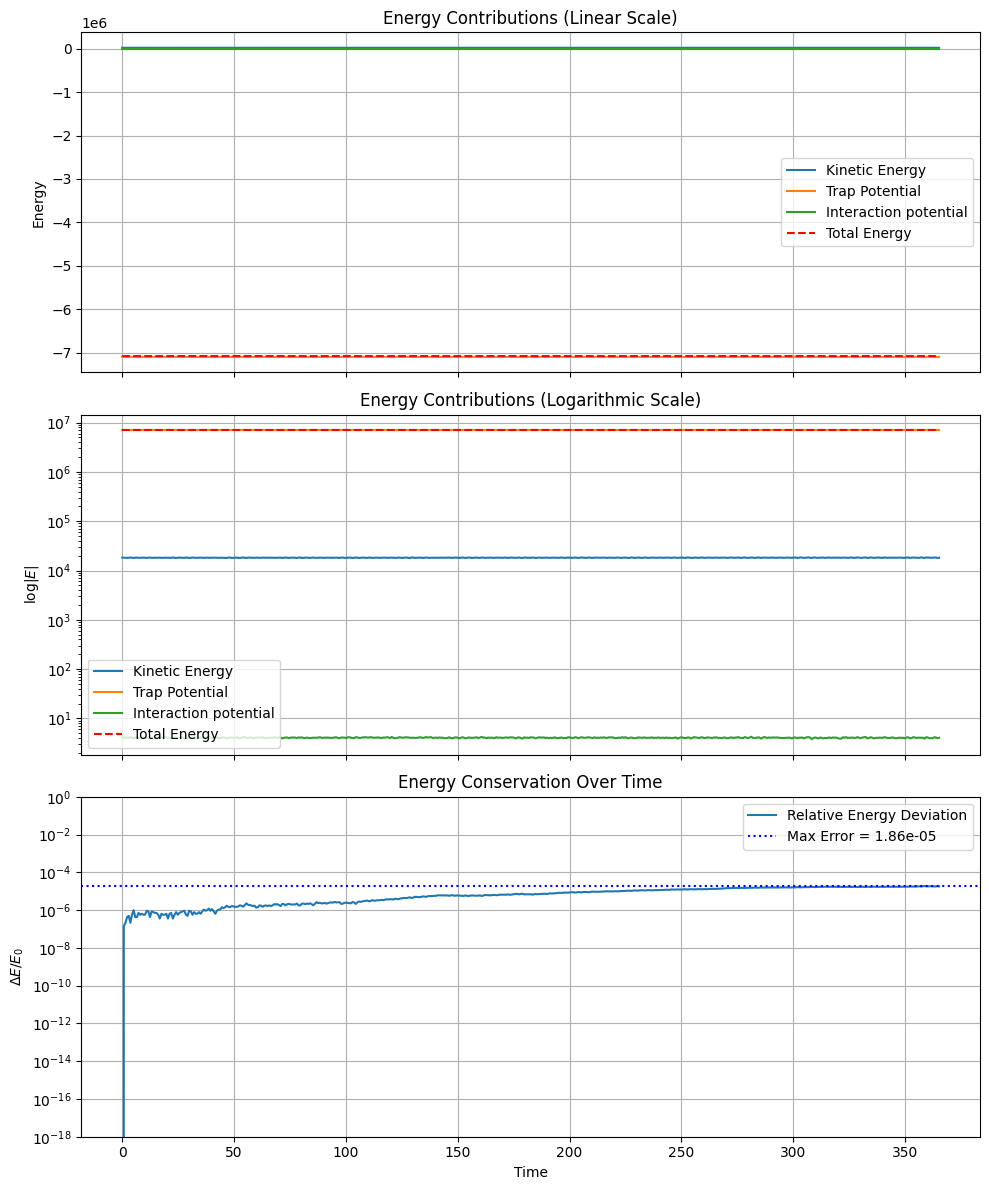

tensor(1.8587e-05, device='cuda:0')

In [9]:
N_PARTICLES = 12062
TEMPERATURE_K = 1e-6
SIMULATION_TIME_S = 0.05    #
TIMESTEP_S = 1e-4            #
SUBSTEPS = 5


TRAP_FREQUENCIES_HZ = (trap_frequencies['freq_x_hz'],trap_frequencies['freq_y_hz'],trap_frequencies['freq_z_hz'])

# ---  Physikalische Wechselwirkungsparameter ---

r0_phys,C_phys = calculate_interaction_strength(10)

print(f"--- Starte Simulation mit N={N_PARTICLES} Teilchen ---")
# ---  Initialisierung ---
# Bestimmt L0, E0, T0, q0, p0, r_dimless, c_dimless
sim_init_params = initialize_one_temp_gaussian_state(
    n_particles=N_PARTICLES,
    temp_k=TEMPERATURE_K,
    omega_phys_hz=TRAP_FREQUENCIES_HZ, # Verwendet harmonische Freq. für Start
    t_end_s=SIMULATION_TIME_S,
    dt_s=TIMESTEP_S,
    r0_phys=r0_phys,
    C_phys=C_phys/100,
    precision=torch.float32,
    device=device
)


# Skalierungsfaktoren
L0 = sim_init_params['L0_m']
E0 = sim_init_params['E0_J']
T0 = sim_init_params['T0_s']


# a) Parameter für die Dipolfalle
trap_params_extended = {
    "P_x": P_x, "P_y": P_y,
    "w0_x": w0_x_SI, "w0_y": w0_y_SI,
    "s0_x": zR_x_SI, "s0_y": zR_y_SI,
    "omega_L": omega_L,
    "omega_0_D1": omega_0_D1, "Gamma_D1": Gamma_D1,
    "omega_0_D2": omega_0_D2, "Gamma_D2": Gamma_D2,
    "L0": L0,
    "E0": E0
}

sim_init_params_rejection_sampling = prepare_one_temp_simulation_rejection(
    n_particles =N_PARTICLES,
    temp_k=TEMPERATURE_K,
    omega_phys_hz=TRAP_FREQUENCIES_HZ,
    t_end_s=SIMULATION_TIME_S,
    dt_s=TIMESTEP_S,
    r0_phys=r0_phys,
    C_phys=C_phys/100,
    trap_force_func=calculate_crossed_beam_dipole_potential,
    trap_params=trap_params_extended,
    precision=torch.float32,
    device=device
)



# b) Parameter für die Paar-Wechselwirkung
pair_params = sim_init_params_rejection_sampling['pair_force_params']

# c) Parameter für den Integrator
integrator_params = {
    "t_values": sim_init_params_rejection_sampling['t_values'],
    "q0": sim_init_params_rejection_sampling['q0'],
    "p0": sim_init_params_rejection_sampling['p0'],
    "precision_type": sim_init_params_rejection_sampling['precision_type'],
    "device": sim_init_params_rejection_sampling['device'],
    "substeps": SUBSTEPS,
}

# --- 6. Simulationsaufruf ---
print("Starte Simulation mit  Dipolfalle")
start_time = time.perf_counter()

results = run_verlet_simulation_general(
    trap_force_func=calculate_crossed_beam_dipole_potential,
    trap_force_params=trap_params_extended,

    pair_force_func=pair_keops_fp,
    pair_force_params=pair_params,

    **integrator_params
)

duration = time.perf_counter() - start_time
print(f"Simulation abgeschlossen in {duration:.2f} Sekunden.")

# --- 7. Ergebnisse plotten ---
plot_energy_and_error(
    results['times'],
    results['kinetic_energy'],
    results['potential_energy_trap'],
    results['potential_energy_pair']
)




In [10]:
# Die Zeitwerte aus den Integrator-Parametern holen
t_tensor = integrator_params['t_values']
# Für die Python-Schleife in CPU-Numpy-Array wandeln (schneller Zugriff)
times_cpu = t_tensor.detach().cpu().numpy()

import numpy as np

# Startwerte sichern
P_x_start = P_x
P_y_start = P_y

# Ziel: Am Ende der Zeit (times_cpu[-1]) nur noch 10% Leistung
end_fraction = 0.0001
t_max = times_cpu[-1] # Endzeitpunkt (dimensionslos oder in Sekunden, je nach deiner Skalierung)

dynamic_trap_params = []

for t in times_cpu:
    # Berechne aktuellen Faktor (geht von 1.0 runter auf 0.1)
    progress = t / t_max
    current_fraction = 1.0 - (1.0 - end_fraction) * progress

    # Kopiere das Basis-Dictionary (WICHTIG: .copy() verwenden!)
    new_params = trap_params_extended.copy()

    # Werte überschreiben
    new_params['P_x'] = P_x_start * current_fraction
    new_params['P_y'] = P_y_start * current_fraction

    dynamic_trap_params.append(new_params)

print("Starte Simulation mit abnehmender Fallenleistung...")
start_time = time.perf_counter()

# WICHTIG: Hier 'dynamic_trap_params' (die Liste) übergeben, nicht das einzelne Dict
results = run_verlet_simulation_dynamic(
    trap_force_func=calculate_crossed_beam_dipole_potential,
    trap_force_params=dynamic_trap_params, # <-- HIER DIE LISTE ÜBERGEBEN

    pair_force_func=pair_keops_fp,
    pair_force_params=pair_params,

    **integrator_params
)

duration = time.perf_counter() - start_time
print(f"Simulation abgeschlossen in {duration:.2f} Sekunden.")

Starte Simulation mit abnehmender Fallenleistung...

Integration abgeschlossen.
Simulation abgeschlossen in 11.27 Sekunden.


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_simulation_results(results, dynamic_params_list=None):
    """
    Plottet Energien, Wolkengröße und Fallenparameter.

    Args:
        results: Das Rückgabe-Dict der Simulation.
        dynamic_params_list: Die Liste der Trap-Parameter (optional, für Plot 3).
    """
    # Daten auf CPU und in Numpy wandeln für Matplotlib
    times = results['times'].detach().cpu().numpy()
    kin_E = results['kinetic_energy'].detach().cpu().numpy()
    pot_trap = results['potential_energy_trap'].detach().cpu().numpy()
    pot_pair = results['potential_energy_pair'].detach().cpu().numpy()

    # Positionen: [Steps, Particles, 3]
    positions = results['positions'].detach().cpu().numpy()

    total_E = kin_E + pot_trap + pot_pair

    # --- Setup Figure ---
    # 3 Subplots untereinander (oder 2, falls keine Params übergeben wurden)
    rows = 3 if dynamic_params_list else 2
    fig, axs = plt.subplots(rows, 1, figsize=(10, 4*rows), sharex=True)

    # --- Plot 1: Energien ---
    ax = axs[0]
    ax.plot(times, kin_E, label='Kinetisch', color='orange', alpha=0.8)
    ax.plot(times, pot_trap, label='Pot. (Falle)', color='blue', alpha=0.8)
    ax.plot(times, pot_pair, label='Pot. (WW)', color='green', alpha=0.8)
    ax.plot(times, total_E, label='Gesamt', color='black', linestyle='--', linewidth=2)
    ax.set_ylabel("Energie [J]")
    ax.set_title("Energieerhaltung & Entwicklung")
    ax.legend(loc='upper right')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

    # Hinweis zur Physik
    if dynamic_params_list:
        ax.text(0.02, 0.05, "Hinweis: E_tot ist nicht konstant\nwegen zeitabh. Potential V(t)",
                transform=ax.transAxes, fontsize=9, bbox=dict(facecolor='white', alpha=0.8))

    # --- Plot 2: Wolkenradius (RMS) ---
    # Wir berechnen die Standardabweichung der Positionen (Maß für die Ausdehnung)
    # axis=1 bedeutet: über die Teilchen mitteln
    std_pos = np.std(positions, axis=1) # Shape: [Steps, 3] (x, y, z)

    ax = axs[1]
    ax.plot(times, std_pos[:, 0], label='σ_x', color='red')
    ax.plot(times, std_pos[:, 1], label='σ_y', color='purple')
    ax.plot(times, std_pos[:, 2], label='σ_z', color='brown')
    ax.set_ylabel("Wolkenradius (RMS) [m]")
    ax.set_title("Dynamik der Wolkengröße")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # --- Plot 3: Fallenparameter (Rampe) ---
    if dynamic_params_list:
        ax = axs[2]
        # Extrahiere P_x und P_y aus der Liste der Dictionaries
        # Wir gehen davon aus, dass 'P_x' in den Dicts existiert
        p_x_vals = [d['P_x'] for d in dynamic_params_list]
        p_y_vals = [d['P_y'] for d in dynamic_params_list]

        ax.plot(times, p_x_vals, label='P_x (Leistung)', color='cyan')
        ax.plot(times, p_y_vals, label='P_y (Leistung)', color='teal', linestyle='--')
        ax.set_ylabel("Leistung [W]")
        ax.set_xlabel("Zeit [s]")
        ax.set_title("Verlauf der Fallenparameter")
        ax.legend()
        ax.grid(True, alpha=0.3)
    else:
        axs[1].set_xlabel("Zeit [s]")

    plt.tight_layout()
    plt.show()

In [12]:
import torch
import time
from typing import Callable, Dict, Union, List

def run_verlet_simulation_evaporation(
    t_values: torch.Tensor,
    q0: torch.Tensor,
    p0: torch.Tensor,
    trap_force_func: Callable,
    trap_force_params: Union[Dict, List[Dict]],
    pair_force_func: Callable,
    pair_force_params: Dict,
    evaporation_radius: float,
    precision_type: torch.dtype = torch.float32,
    device: torch.device = torch.device('cpu'),
    substeps: int = 100,
    silent: bool = False,
    **kwargs
) -> Dict[str, torch.Tensor]:

    with torch.no_grad():
        num_save_points, n_particles_total = t_values.size(0), q0.size(0)

        # 1. Output-Speicher mit nan initialiserien
        q_out = torch.full((num_save_points, n_particles_total, 3), float('nan'), dtype=precision_type, device=device)
        p_out = torch.full((num_save_points, n_particles_total, 3), float('nan'), dtype=precision_type, device=device)

        # Energien
        kinetic_energy_out = torch.zeros(num_save_points, dtype=precision_type, device=device)
        potential_trap_out = torch.zeros(num_save_points, dtype=precision_type, device=device)
        potential_pair_out = torch.zeros(num_save_points, dtype=precision_type, device=device)
        n_active_out = torch.zeros(num_save_points, dtype=torch.int32, device=device)


        q = q0.to(device, precision_type).clone()
        p = p0.to(device, precision_type).clone()

        # WICHTIG: Dieser Vektor merkt sich die ursprünglichen IDs der aktiven Teilchen
        active_indices = torch.arange(n_particles_total, device=device)

        # Trap Parameter Handling, ist true wenn liste von paramters
        is_dynamic_trap = isinstance(trap_force_params, list)
        current_trap_params = trap_force_params[0] if is_dynamic_trap else trap_force_params

        # --- Initialisierung ---
        # Berechnung nur für aktive Teilchen
        f_trap, pot_trap, _ = trap_force_func(q, **current_trap_params)
        f_pair, pot_pair = pair_force_func(q, **pair_force_params)
        a = f_trap + f_pair

        # Speichern (Scatter-Operation: Nur an die Positionen der aktiven Indices schreiben)
        q_out[0, active_indices] = q
        p_out[0, active_indices] = p
        kinetic_energy_out[0] = 0.5 * torch.sum(p**2)
        potential_trap_out[0] = pot_trap
        potential_pair_out[0] = pot_pair
        n_active_out[0] = len(active_indices)

        # --- Hauptschleife ---
        for i in range(1, num_save_points):
            loop_start_time = time.perf_counter()

            Dt = t_values[i] - t_values[i - 1]
            dt = Dt / substeps
            dt_half = 0.5 * dt

            if is_dynamic_trap:
                current_trap_params = trap_force_params[i]
                # Kraft-Update wegen Parameteränderung
                f_trap, _, _ = trap_force_func(q, **current_trap_params)
                a = f_trap + f_pair # f_pair ist noch kompatibel, da q sich nicht geändert hat

            # --- Substeps ---
            for _ in range(substeps):
                # 1. Kick & Drift
                p.add_(a, alpha=dt_half)
                q.add_(p, alpha=dt)

                # 2. EVAPORATION
                # Berechne Radius im Quadrat
                r_sq = torch.sum(q**2, dim=1)

                # Maske: True wenn Teilchen noch in falle ist
                keep_mask = r_sq < evaporation_radius**2

                 # (~keep_mask).any() prüft ob mindestens ein False dabei ist
                if not keep_mask.all():
                    # entferen false teilchen
                    q = q[keep_mask]
                    p = p[keep_mask]

                    # Auch die IDs updaten, damit wir wissen, wer übrig ist
                    active_indices = active_indices[keep_mask]

                    # Wenn alle weg sind, können wir abbrechen (spart Zeit)
                    if len(active_indices) == 0:
                        break

                    # Da q kleiner geworden ist, MÜSSEN wir Kräfte komplett neu berechnen
                    # (Wir können alte Kräfte nicht wiederverwenden, Dimension passt nicht mehr)
                    f_trap, _, _ = trap_force_func(q, **current_trap_params)
                    f_pair, _ = pair_force_func(q, **pair_force_params)
                    a = f_trap + f_pair

                    # Wichtig: p wurde oben schon halb geupdated.
                    # Der nächste Kick (unten) braucht das neue a. Alles korrekt.
                else:
                    # Standardfall (niemand entkommen): Normale Kraftberechnung
                    f_trap, _, _ = trap_force_func(q, **current_trap_params)
                    f_pair, _ = pair_force_func(q, **pair_force_params)
                    a = f_trap + f_pair

                # 3. Kick (zweite Hälfte)
                if len(active_indices) > 0:
                    p.add_(a, alpha=dt_half)

            # --- Abbruch wenn leer ---
            if len(active_indices) == 0:
                print(f"\rIntegration {100 * (i + 1) / num_save_points:.0f}% | Alle Teilchen verloren!", end='')
                # Rest der Arrays ist schon mit 0 oder NaN initialisiert
                break

            # --- Speichern ---
            # Wir nutzen active_indices, um die Daten an die richtige Stelle in der großen Matrix zu schreiben
            q_out[i, active_indices] = q
            p_out[i, active_indices] = p

            kinetic_energy_out[i] = 0.5 * torch.sum(p**2)

            # Potentiale für Statistik noch einmal sauber berechnen (oder aus Loop retten)
            # Hier zur Sicherheit neu berechnen, ist billig für subset
            _, pot_trap, _ = trap_force_func(q, **current_trap_params)
            _, pot_pair = pair_force_func(q, **pair_force_params)

            potential_trap_out[i] = pot_trap
            potential_pair_out[i] = pot_pair
            n_active_out[i] = len(active_indices)

            # Logging
            if not silent:
                loop_end_time = time.perf_counter()
                eta_seconds = int((loop_end_time - loop_start_time) * (num_save_points - 1 - i))
                print(f"\rIntegration {100 * (i + 1) / num_save_points:.0f}% "
                      f"| N: {len(active_indices)} "
                      f"| ETA: {eta_seconds // 60}m {eta_seconds % 60}s", end='', flush=True)

        print("\nIntegration abgeschlossen.")

        return {
            "times": t_values,
            "positions": q_out,
            "momenta": p_out,
            "kinetic_energy": kinetic_energy_out,
            "potential_energy_trap": potential_trap_out,
            "potential_energy_pair": potential_pair_out,
            "n_active": n_active_out
        }

In [13]:
def generate_exact_thermal_state(
    n_particles: int,
    temp_k: float,
    trap_func: Callable,
    trap_params: Dict,
    L0: float, # Wichtig für Skalierung!
    bounds_SI: float, # Wie weit suchen wir? z.B. 4*w0
    device: torch.device
):
    """
    Erzeugt eine Startverteilung, die EXAKT zur übergebenen Trap-Funktion passt.
    """
    print("Generiere exakten thermischen Zustand (Custom Sampling)...")

    q_list = []
    n_found = 0

    # Konstanten
    k_B = 1.380649e-23
    beta = 1.0 / (k_B * temp_k)

    # Referenz-Potential bei 0 (Minimum)
    # Wir brauchen das, um die Wahrscheinlichkeit P=1 im Zentrum zu setzen.
    dummy_zero = torch.zeros((1, 3), device=device, dtype=torch.float32)
    _, V_min_J, _ = trap_func(dummy_zero, **trap_params)
    V_min = V_min_J.item()

    # Batch-Größe für Effizienz
    batch_size = n_particles * 2

    while n_found < n_particles:
        # 1. Zufällige Punkte in Box [-bounds, +bounds] (SI-Einheiten!)
        # Shape: [Batch, 3]
        r_SI = (torch.rand((batch_size, 3), device=device) * 2.0 - 1.0) * bounds_SI

        # 2. Umrechnen in dimensionslos für die Trap-Funktion
        q_test = r_SI / L0

        # 3. Potential berechnen (Return muss Joule sein!)
        _, V_pot_J, _ = trap_func(q_test, **trap_params)

        # 4. Boltzmann-Faktor berechnen: P = exp( -(V - V_min) / kT )
        # Wir ziehen V_min ab, damit der Exponent negativ bleibt (V >= V_min)
        # Wenn V_pot riesig ist (außerhalb), wird P -> 0.
        prob = torch.exp(-beta * (V_pot_J - V_min))

        # 5. Akzeptieren / Verwerfen
        random_vals = torch.rand(batch_size, device=device)
        mask = random_vals < prob

        accepted_q = q_test[mask]

        q_list.append(accepted_q)
        n_found += accepted_q.size(0)

    # Zusammenfügen und auf N kürzen
    q_final = torch.cat(q_list, dim=0)[:n_particles]

    print(f"Sampling fertig. {n_particles} Teilchen platziert.")
    return q_final

In [14]:
import torch
import numpy as np
import time
import matplotlib.pyplot as plt

# 1. Device wählen (WICHTIG für Speed!)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Laufe auf: {device}")

# --- Deine Parameter und Initialisierung ---
# (Ich nehme an, sim_init_params_rejection_sampling ist bereits ausgeführt)

# WICHTIG: Skalierungsparameter holen für Einheiten-Umrechnung!
L0 = sim_init_params_rejection_sampling['L0_m']

# Sicherstellen, dass die Tensoren auf dem richtigen Device sind
q0 = sim_init_params_rejection_sampling['q0'].to(device)
p0 = sim_init_params_rejection_sampling['p0'].to(device)
t_values = sim_init_params_rejection_sampling['t_values'].to(device)

# Basis-Parameter holen
pair_params = sim_init_params_rejection_sampling['pair_force_params']
# trap_params_extended sollte hier dein Start-Dictionary sein (100% Leistung)

# --- 2. Dynamische Parameter-Liste erstellen (Die Rampe) ---
print("Erstelle dynamische Parameter-Rampe...")

# Zeitwerte für den Loop auf CPU holen
times_cpu = t_values.detach().cpu().numpy()
t_max = times_cpu[-1]
tau = t_max / 30  # Zeitkonstante für exponentiellen Abfall

dynamic_trap_params = []
P_x_start = trap_params_extended['P_x']
P_y_start = trap_params_extended['P_y']

for t in times_cpu:
    # Exponentielle Rampe: P(t) = P0 * exp(-t/tau)
    # Aktuell auf 1 gesetzt (kein Decay), wie in deinem Code gewünscht.
    # Zum Aktivieren: decay = np.exp(-t / tau)
    decay = np.exp(-t / tau)

    # Dict kopieren und Werte updaten
    current_params = trap_params_extended.copy()
    current_params['P_x'] = P_x_start * decay
    current_params['P_y'] = P_y_start * decay

    dynamic_trap_params.append(current_params)

# --- 3. Evaporations-Radius festlegen ---
# Teilchen entkommen, wenn sie weiter weg sind als dieser Radius.
w0_SI = trap_params_extended['w0_x']

# Radius in SI-Einheiten (Meter)
EVAP_RADIUS_SI = w0_SI  # Oder z.B. 3 * w0_SI

# WICHTIG: Umrechnung in dimensionslose Einheiten für den Algorithmus
EVAP_RADIUS_DIMLESS = EVAP_RADIUS_SI / L0

print(f"L0 Skalierung:         {L0:.2e} m")
print(f"Evap Radius (SI):      {EVAP_RADIUS_SI*1e6:.1f} µm")
print(f"Evap Radius (Dimless): {EVAP_RADIUS_DIMLESS:.4f}")



# --- 4. Simulation Starten (Speedup Version) ---
print(f"Starte Simulation mit {q0.size(0)} Teilchen...")
start_time = time.perf_counter()

results = run_verlet_simulation_evaporation_speedup(
    t_values=t_values,
    q0=q0,
    p0=p0,

    # Physik-Funktionen
    trap_force_func=calculate_crossed_beam_dipole_potential,
    trap_force_params=dynamic_trap_params, # Hier die Liste!

    pair_force_func=pair_keops_fp,
    pair_force_params=pair_params,

    # Evaporation: HIER dimensionslos übergeben!
    evaporation_radius=EVAP_RADIUS_DIMLESS,

    # Integrator Einstellungen
    substeps=SUBSTEPS, # z.B. 5
    device=device,
    precision_type=torch.float32,
    silent=False # Zeigt Fortschrittsbalken und Atomzahl an
)

if torch.cuda.is_available():
    torch.cuda.synchronize() # Nur bei GPU nötig für exakte Zeitmessung

duration = time.perf_counter() - start_time
print(f"\nSimulation fertig in {duration:.2f} s")

# --- Plot Funktion ---
def plot_simulation_final(results, dynamic_params_list, L0_scale):
    # Daten auf CPU holen
    times = results['times'].detach().cpu().numpy()
    kin_E = results['kinetic_energy'].detach().cpu().numpy()
    pot_trap = results['potential_energy_trap'].detach().cpu().numpy()
    pot_pair = results['potential_energy_pair'].detach().cpu().numpy()
    n_active = results['n_active'].detach().cpu().numpy()

    # Positionen für Radius-Berechnung
    # results['positions'] enthält NaNs für verlorene Teilchen.
    # np.nanstd ignoriert NaNs automatisch.
    positions = results['positions'].detach().cpu().numpy()

    # --- FEHLERBEHEBUNG HIER ---
    # L0_scale ist ein Tensor, wir brauchen den float-Wert (.item())
    L0_float = L0_scale.item() if isinstance(L0_scale, torch.Tensor) else L0_scale

    # Umrechnung zurück in Meter mit L0_float
    std_pos = np.nanstd(positions, axis=1) * L0_float # RMS Radius in Meter

    # Setup Plot
    fig, axs = plt.subplots(4, 1, figsize=(10, 14), sharex=True)

    # 1. Energien
    E_tot = kin_E + pot_trap + pot_pair
    axs[0].plot(times, kin_E, label='Kinetisch (Temp)', color='orange')
    axs[0].plot(times, pot_trap, label='Pot (Falle)', color='blue')
    axs[0].plot(times, pot_pair, label='Pot (WW)', color='green')
    axs[0].plot(times, E_tot, 'k--', label='Gesamt (Aktive)', alpha=0.5)
    axs[0].set_ylabel("Energie [J]")
    axs[0].set_title("Energie der *gefangenen* Wolke")
    axs[0].legend(loc='right')
    axs[0].grid(True, alpha=0.3)

    # 2. Wolkengröße
    axs[1].plot(times, std_pos[:, 0], label='x-Breite')
    axs[1].plot(times, std_pos[:, 1], label='y-Breite')
    axs[1].plot(times, std_pos[:, 2], label='z-Breite')
    axs[1].set_ylabel("Wolkenradius [m]")
    axs[1].set_title("Ausdehnung (Expansion durch schwächere Falle)")
    axs[1].legend()
    axs[1].grid(True, alpha=0.3)

    # 3. Atomzahl (Verlust)
    axs[2].plot(times, n_active, color='black', linewidth=2)
    axs[2].set_ylabel("Anzahl Atome N(t)")
    axs[2].set_title(f"Evaporation (Start: {n_active[0]} -> Ende: {n_active[-1]})")
    axs[2].grid(True, alpha=0.3)

    # Prozentanzeige im Plot
    if n_active[0] > 0:
        loss_pct = 100 * (1 - n_active[-1]/n_active[0])
        axs[2].text(0.5, 0.5, f"Verlust: {loss_pct:.1f}%",
                    transform=axs[2].transAxes, fontsize=12,
                    bbox=dict(facecolor='white', alpha=0.8))

    # 4. Fallenleistung (Check der Rampe)
    # Sicherstellen, dass wir hier keine GPU-Tensoren plotten
    P_x_vals = []
    for d in dynamic_params_list:
        val = d['P_x']
        # Falls P_x noch ein Tensor ist, in float wandeln
        if isinstance(val, torch.Tensor):
            val = val.item()
        P_x_vals.append(val)

    axs[3].plot(times, P_x_vals, color='red', linestyle='--')
    axs[3].set_ylabel("Leistung P_x [W]")
    axs[3].set_xlabel("Zeit [s]")
    axs[3].set_title("Rampe der Fallenleistung")
    axs[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- AUFRUF ---
# L0 ist noch ein Tensor, wird aber jetzt in der Funktion korrekt behandelt
plot_simulation_final(results, dynamic_trap_params, L0_scale=L0)

Laufe auf: cuda
Erstelle dynamische Parameter-Rampe...
L0 Skalierung:         1.34e-06 m
Evap Radius (SI):      41.0 µm
Evap Radius (Dimless): 30.6230
Starte Simulation mit 12062 Teilchen...


NameError: name 'run_verlet_simulation_evaporation_speedup' is not defined

In [ ]:
import torch
import numpy as np
import time
import matplotlib.pyplot as plt

# 1. Device wählen (WICHTIG für Speed!)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Laufe auf: {device}")

# --- Deine Parameter und Initialisierung ---
# (Ich nehme an, sim_init_params_rejection_sampling ist bereits ausgeführt)

# WICHTIG: Skalierungsparameter holen für Einheiten-Umrechnung!
L0 = sim_init_params_rejection_sampling['L0_m']

# Sicherstellen, dass die Tensoren auf dem richtigen Device sind
q0 = sim_init_params_rejection_sampling['q0'].to(device)
p0 = sim_init_params_rejection_sampling['p0'].to(device)
t_values = sim_init_params_rejection_sampling['t_values'].to(device)

# Basis-Parameter holen
pair_params = sim_init_params_rejection_sampling['pair_force_params']
# trap_params_extended sollte hier dein Start-Dictionary sein (100% Leistung)

# --- 2. Dynamische Parameter-Liste erstellen (Die Rampe) ---
print("Erstelle dynamische Parameter-Rampe...")

# Zeitwerte für den Loop auf CPU holen
times_cpu = t_values.detach().cpu().numpy()
t_max = times_cpu[-1]
tau = t_max / 11 # Zeitkonstante für exponentiellen Abfall

dynamic_trap_params = []
P_x_start = trap_params_extended['P_x']
P_y_start = trap_params_extended['P_y']

for t in times_cpu:
    # Exponentielle Rampe: P(t) = P0 * exp(-t/tau)
    # Aktuell auf decay gesetzt
    decay = np.exp(-t / tau)

    # Dict kopieren und Werte updaten
    current_params = trap_params_extended.copy()
    current_params['P_x'] = P_x_start * decay
    current_params['P_y'] = P_y_start * decay

    dynamic_trap_params.append(current_params)

# --- 3. Evaporations-Radius festlegen ---
# Teilchen entkommen, wenn sie weiter weg sind als dieser Radius.
w0_SI = trap_params_extended['w0_x']

# Radius in SI-Einheiten (Meter)
EVAP_RADIUS_SI = w0_SI  # Oder z.B. 3 * w0_SI

# WICHTIG: Umrechnung in dimensionslose Einheiten für den Algorithmus
EVAP_RADIUS_DIMLESS = EVAP_RADIUS_SI / L0

print(f"L0 Skalierung:         {L0:.2e} m")
print(f"Evap Radius (SI):      {EVAP_RADIUS_SI*1e6:.1f} µm")
print(f"Evap Radius (Dimless): {EVAP_RADIUS_DIMLESS:.4f}")

# --- 4. Simulation Starten (Speedup Version) ---
print(f"Starte Simulation mit {q0.size(0)} Teilchen...")
start_time = time.perf_counter()

results = run_verlet_simulation_evaporation_speedup(
    t_values=t_values,
    q0=q0,
    p0=p0,

    # Physik-Funktionen
    trap_force_func=calculate_crossed_beam_dipole_potential,
    trap_force_params=dynamic_trap_params, # Hier die Liste!

    pair_force_func=pair_keops_fp,
    pair_force_params=pair_params,

    # Evaporation: HIER dimensionslos übergeben!
    evaporation_radius=EVAP_RADIUS_DIMLESS,

    # Integrator Einstellungen
    substeps=SUBSTEPS, # z.B. 5
    device=device,
    precision_type=torch.float32,
    silent=False # Zeigt Fortschrittsbalken und Atomzahl an
)

if torch.cuda.is_available():
    torch.cuda.synchronize() # Nur bei GPU nötig für exakte Zeitmessung

duration = time.perf_counter() - start_time
print(f"\nSimulation fertig in {duration:.2f} s")

# --- Plot Funktion ---
def plot_simulation_final(results, dynamic_params_list, L0_scale, evap_radius_SI=None):
    # Daten auf CPU holen
    times = results['times'].detach().cpu().numpy()
    kin_E = results['kinetic_energy'].detach().cpu().numpy()
    pot_trap = results['potential_energy_trap'].detach().cpu().numpy()
    pot_pair = results['potential_energy_pair'].detach().cpu().numpy()
    n_active = results['n_active'].detach().cpu().numpy()

    # Positionen für Radius-Berechnung
    # results['positions'] enthält NaNs für verlorene Teilchen.
    # np.nanstd ignoriert NaNs automatisch.
    positions = results['positions'].detach().cpu().numpy()

    # --- FEHLERBEHEBUNG HIER ---
    # L0_scale ist ein Tensor, wir brauchen den float-Wert (.item())
    L0_float = L0_scale.item() if isinstance(L0_scale, torch.Tensor) else L0_scale

    # Umrechnung zurück in Meter mit L0_float
    std_pos = np.nanstd(positions, axis=1) * L0_float # RMS Radius in Meter

    # Setup Plot
    fig, axs = plt.subplots(4, 1, figsize=(10, 14), sharex=True)

    # 1. Energien
    E_tot = kin_E + pot_trap + pot_pair
    axs[0].plot(times, kin_E, label='Kinetisch (Temp)', color='orange')
    axs[0].plot(times, pot_trap, label='Pot (Falle)', color='blue')
    axs[0].plot(times, pot_pair, label='Pot (WW)', color='green')
    axs[0].plot(times, E_tot, 'k--', label='Gesamt (Aktive)', alpha=0.5)
    axs[0].set_ylabel("Energie [J]")
    axs[0].set_title("Energie der *gefangenen* Wolke")
    axs[0].legend(loc='right')
    axs[0].grid(True, alpha=0.3)

    # 2. Wolkengröße
    axs[1].plot(times, std_pos[:, 0], label='x-Breite')
    axs[1].plot(times, std_pos[:, 1], label='y-Breite')
    axs[1].plot(times, std_pos[:, 2], label='z-Breite')

    # --- NEU: Cutoff-Radius einzeichnen ---
    if evap_radius_SI is not None:
        axs[1].axhline(y=evap_radius_SI, color='red', linestyle='--', linewidth=1.5, label='Cutoff Radius')

    axs[1].set_ylabel("Wolkenradius [m]")
    axs[1].set_title("Ausdehnung (Expansion durch schwächere Falle)")
    axs[1].legend()
    axs[1].grid(True, alpha=0.3)

    # 3. Atomzahl (Verlust)
    axs[2].plot(times, n_active, color='black', linewidth=2)
    axs[2].set_ylabel("Anzahl Atome N(t)")
    axs[2].set_title(f"Evaporation (Start: {n_active[0]} -> Ende: {n_active[-1]})")
    axs[2].grid(True, alpha=0.3)

    # Prozentanzeige im Plot
    if n_active[0] > 0:
        loss_pct = 100 * (1 - n_active[-1]/n_active[0])
        axs[2].text(0.5, 0.5, f"Verlust: {loss_pct:.1f}%",
                    transform=axs[2].transAxes, fontsize=12,
                    bbox=dict(facecolor='white', alpha=0.8))

    # 4. Fallenleistung (Check der Rampe)
    # Sicherstellen, dass wir hier keine GPU-Tensoren plotten
    P_x_vals = []
    for d in dynamic_params_list:
        val = d['P_x']
        # Falls P_x noch ein Tensor ist, in float wandeln
        if isinstance(val, torch.Tensor):
            val = val.item()
        P_x_vals.append(val)

    axs[3].plot(times, P_x_vals, color='red', linestyle='--')
    axs[3].set_ylabel("Leistung P_x [W]")
    axs[3].set_xlabel("Zeit [s]")
    axs[3].set_title("Rampe der Fallenleistung")
    axs[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- AUFRUF ---
# Wir übergeben jetzt zusätzlich EVAP_RADIUS_SI
plot_simulation_final(results, dynamic_trap_params, L0_scale=L0, evap_radius_SI=EVAP_RADIUS_SI)